# Preliminarna statistična analiza LLM napovedi

Ta zvezek analizira rezultate eksperimenta `llm-trader`.

## 1. Uvozi in poti

V tem delu naložimo knjižnice in nastavimo poti do projekta z rezultati ter map, kamor bomo shranjevali tabele in slike.


In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:
cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    analysis_dir = cwd.parent
else:
    analysis_dir = cwd

magistrska_dir = analysis_dir.parent
trader_dir = magistrska_dir / "llm-trader"
results_dir = trader_dir / "results"
output_tables_dir = analysis_dir / "outputs" / "tables"
output_figures_dir = analysis_dir / "outputs" / "figures"

output_tables_dir.mkdir(parents=True, exist_ok=True)
output_figures_dir.mkdir(parents=True, exist_ok=True)


## 2. Preslikava konfiguracij

Vsaka konfiguracija predstavlja kombinacijo treh eksperimentalnih pogojev:

- ali model vidi trenutne tržne verjetnosti,
- ali model vidi novice,
- ali je v pozivu zapisano, da so drugi udeleženci `llms`, `humans` ali pa niso omenjeni.

To preslikavo uporabimo zato, da lahko rezultate analiziramo po vsebinskih pogojih, ne samo po številki konfiguracije.


In [3]:
config_map = pd.DataFrame(
    [
        {"configuration_id": "1", "show_market_probabilities": True, "news_shown": True, "other_traders": "llms"},
        {"configuration_id": "2", "show_market_probabilities": True, "news_shown": False, "other_traders": "llms"},
        {"configuration_id": "3", "show_market_probabilities": True, "news_shown": True, "other_traders": "humans"},
        {"configuration_id": "4", "show_market_probabilities": True, "news_shown": False, "other_traders": "humans"},
        {"configuration_id": "5", "show_market_probabilities": True, "news_shown": True, "other_traders": "none"},
        {"configuration_id": "6", "show_market_probabilities": True, "news_shown": False, "other_traders": "none"},
        {"configuration_id": "7", "show_market_probabilities": False, "news_shown": True, "other_traders": "llms"},
        {"configuration_id": "8", "show_market_probabilities": False, "news_shown": False, "other_traders": "llms"},
        {"configuration_id": "9", "show_market_probabilities": False, "news_shown": True, "other_traders": "humans"},
        {"configuration_id": "10", "show_market_probabilities": False, "news_shown": False, "other_traders": "humans"},
        {"configuration_id": "11", "show_market_probabilities": False, "news_shown": True, "other_traders": "none"},
        {"configuration_id": "12", "show_market_probabilities": False, "news_shown": False, "other_traders": "none"},
    ]
)

config_map


,configuration_id,show_market_probabilities,news_shown,other_traders
0,1,True,True,llms
1,2,True,False,llms
2,3,True,True,humans
3,4,True,False,humans
4,5,True,True,none
5,6,True,False,none
6,7,False,True,llms
7,8,False,False,llms
8,9,False,True,humans
9,10,False,False,humans


## 3. Nalaganje napovedi in priprava podatkov

Naložimo vse datoteke `predictions.json` iz mape `llm-trader/results`. Vsaka vrstica v končni tabeli predstavlja eno napoved modela za en trg, en datum in eno konfiguracijo.


In [4]:
def extract_market_probability_yes(prompt: str) -> float:
    match = re.search(r"Current market probabilities:\s*YES:\s*([0-9.]+)", prompt)
    if match is None:
        return np.nan
    return float(match.group(1))


records = []
prediction_paths = sorted(results_dir.glob("*/predictions.json"))

for path in prediction_paths:
    with path.open("r", encoding="utf-8") as f:
        predictions = json.load(f)
    
    for row in predictions:
        records.append(
            {
                "run_dir": path.parent.name,
                "source_file": str(path),
                "market_id": row["market_id"],
                "configuration_id": str(row["configuration_id"]),
                "date": pd.to_datetime(row["date"]),
                "p_yes": float(row["p_yes"]),
                "p_no": float(row["p_no"]),
                "reasoning": row.get("reasoning", ""),
                "rendered_prompt": row.get("rendered_prompt", ""),
                "market_probability_yes": extract_market_probability_yes(row.get("rendered_prompt", "")),
            }
        )

df = pd.DataFrame(records)
df = df.merge(config_map, on="configuration_id", how="left")
df["subject_id"] = df["market_id"] + "__" + df["date"].dt.strftime("%Y-%m-%d")

df = df.sort_values(["market_id", "date", "configuration_id"]).reset_index(drop=True)

print(f"Prediction files loaded: {len(prediction_paths)}")
print(f"Rows loaded: {len(df)}")
print(f"Markets: {df['market_id'].nunique()}")
print(f"Configurations: {df['configuration_id'].nunique()}")
print(f"Market-date subjects: {df['subject_id'].nunique()}")

df.head()


Prediction files loaded: 72
Rows loaded: 1440
Markets: 6
Configurations: 12
Market-date subjects: 120


,run_dir,source_file,market_id,configuration_id,date,p_yes,p_no,reasoning,rendered_prompt,market_probability_yes,show_market_probabilities,news_shown,other_traders,subject_id
0,fed_decision_in_december_1_20260429_154652,/Users/marjanmeglen/Desktop/magistrska/llm-tra...,fed_decision_in_december,1,2025-11-20,0.280,0.720,The current market probability is 0.305. The p...,You are participating in a prediction market. ...,0.305,True,True,llms,fed_decision_in_december__2025-11-20
1,fed_decision_in_december_10_20260429_161245,/Users/marjanmeglen/Desktop/magistrska/llm-tra...,fed_decision_in_december,10,2025-11-20,0.500,0.500,There is no provided news or economic data reg...,You are participating in a prediction market. ...,NaN,False,False,humans,fed_decision_in_december__2025-11-20
2,fed_decision_in_december_11_20260429_161328,/Users/marjanmeglen/Desktop/magistrska/llm-tra...,fed_decision_in_december,11,2025-11-20,0.300,0.700,The provided news indicates that inflation rem...,You are participating in a prediction market. ...,NaN,False,True,none,fed_decision_in_december__2025-11-20
3,fed_decision_in_december_12_20260429_161823,/Users/marjanmeglen/Desktop/magistrska/llm-tra...,fed_decision_in_december,12,2025-11-20,0.500,0.500,There is no provided information regarding cur...,You are participating in a prediction market. ...,NaN,False,False,none,fed_decision_in_december__2025-11-20
4,fed_decision_in_december_2_20260429_155127,/Users/marjanmeglen/Desktop/magistrska/llm-tra...,fed_decision_in_december,2,2025-11-20,0.305,0.695,The current market probability is 0.305. Witho...,You are participating in a prediction market. ...,0.305,True,False,llms,fed_decision_in_december__2025-11-20


In [5]:
checks = {
    "missing_config_mapping": int(df["show_market_probabilities"].isna().sum()),
    "p_yes_outside_0_1": int(((df["p_yes"] < 0) | (df["p_yes"] > 1)).sum()),
    "p_no_outside_0_1": int(((df["p_no"] < 0) | (df["p_no"] > 1)).sum()),
    "probabilities_not_summing_to_1": int(((df["p_yes"] + df["p_no"] - 1).abs() > 1e-5).sum()),
    "duplicate_subject_config_rows": int(df.duplicated(["subject_id", "configuration_id"]).sum()),
}

pd.Series(checks)


missing_config_mapping            0
p_yes_outside_0_1                 0
p_no_outside_0_1                  0
probabilities_not_summing_to_1    0
duplicate_subject_config_rows     0
dtype: int64

## 4. Opisne statistike za `p_yes`


In [6]:
summary_by_market_config = (
    df.groupby(["market_id", "configuration_id", "show_market_probabilities", "news_shown", "other_traders"])
    .agg(
        n=("p_yes", "size"),
        mean_p_yes=("p_yes", "mean"),
        sd_p_yes=("p_yes", "std"),
        min_p_yes=("p_yes", "min"),
        max_p_yes=("p_yes", "max"),
    )
    .reset_index()
    .sort_values(["market_id", "configuration_id"], key=lambda s: s.astype(int) if s.name == "configuration_id" else s)
)

summary_by_market_config.to_csv(output_tables_dir / "summary_by_market_config.csv", index=False)
summary_by_market_config


,market_id,configuration_id,show_market_probabilities,news_shown,other_traders,n,mean_p_yes,sd_p_yes,min_p_yes,max_p_yes
0,fed_decision_in_december,1,True,True,llms,20,0.72400,0.191570,0.280,0.910
4,fed_decision_in_december,2,True,False,llms,20,0.79900,0.186756,0.305,0.935
5,fed_decision_in_december,3,True,True,humans,20,0.75025,0.203136,0.280,0.935
6,fed_decision_in_december,4,True,False,humans,20,0.79900,0.186756,0.305,0.935
7,fed_decision_in_december,5,True,True,none,20,0.73300,0.201223,0.300,0.935
...,...,...,...,...,...,...,...,...,...,...
70,who_will_be_inaugurated_as_president,8,False,False,llms,20,0.99000,0.000000,0.990,0.990
71,who_will_be_inaugurated_as_president,9,False,True,humans,20,0.96600,0.109708,0.500,1.000
61,who_will_be_inaugurated_as_president,10,False,False,humans,20,0.99000,0.000000,0.990,0.990
62,who_will_be_inaugurated_as_president,11,False,True,none,20,0.98850,0.009333,0.950,1.000


## 5. Vizualizacije


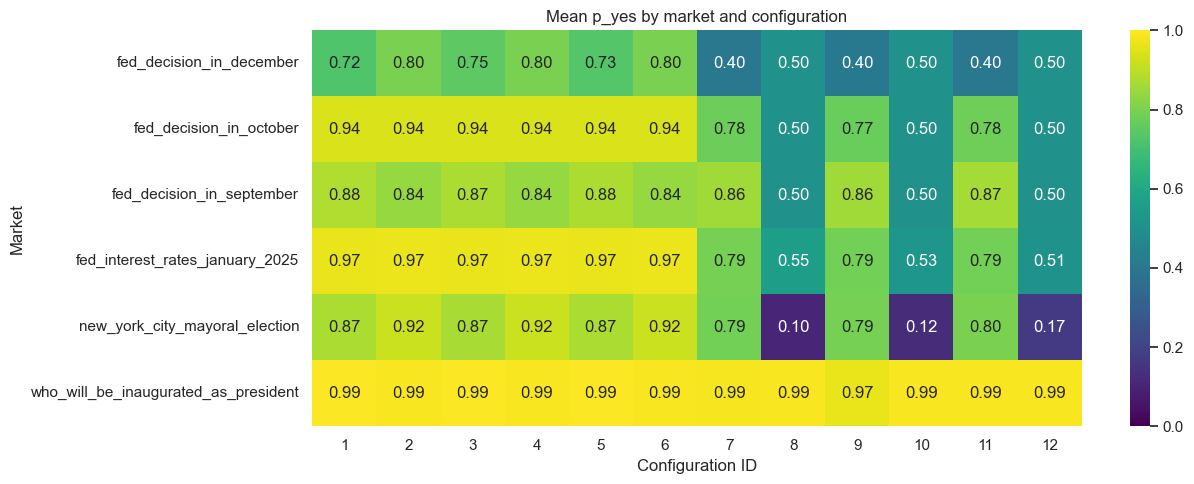

In [8]:
heatmap_data = df.pivot_table(index="market_id", columns="configuration_id", values="p_yes", aggfunc="mean")
heatmap_data = heatmap_data[[str(i) for i in range(1, 13)]]

plt.figure(figsize=(13, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Mean p_yes by market and configuration")
plt.xlabel("Configuration ID")
plt.ylabel("Market")
plt.tight_layout()
plt.savefig(output_figures_dir / "heatmap_mean_p_yes_market_config.png", dpi=150)
plt.show()


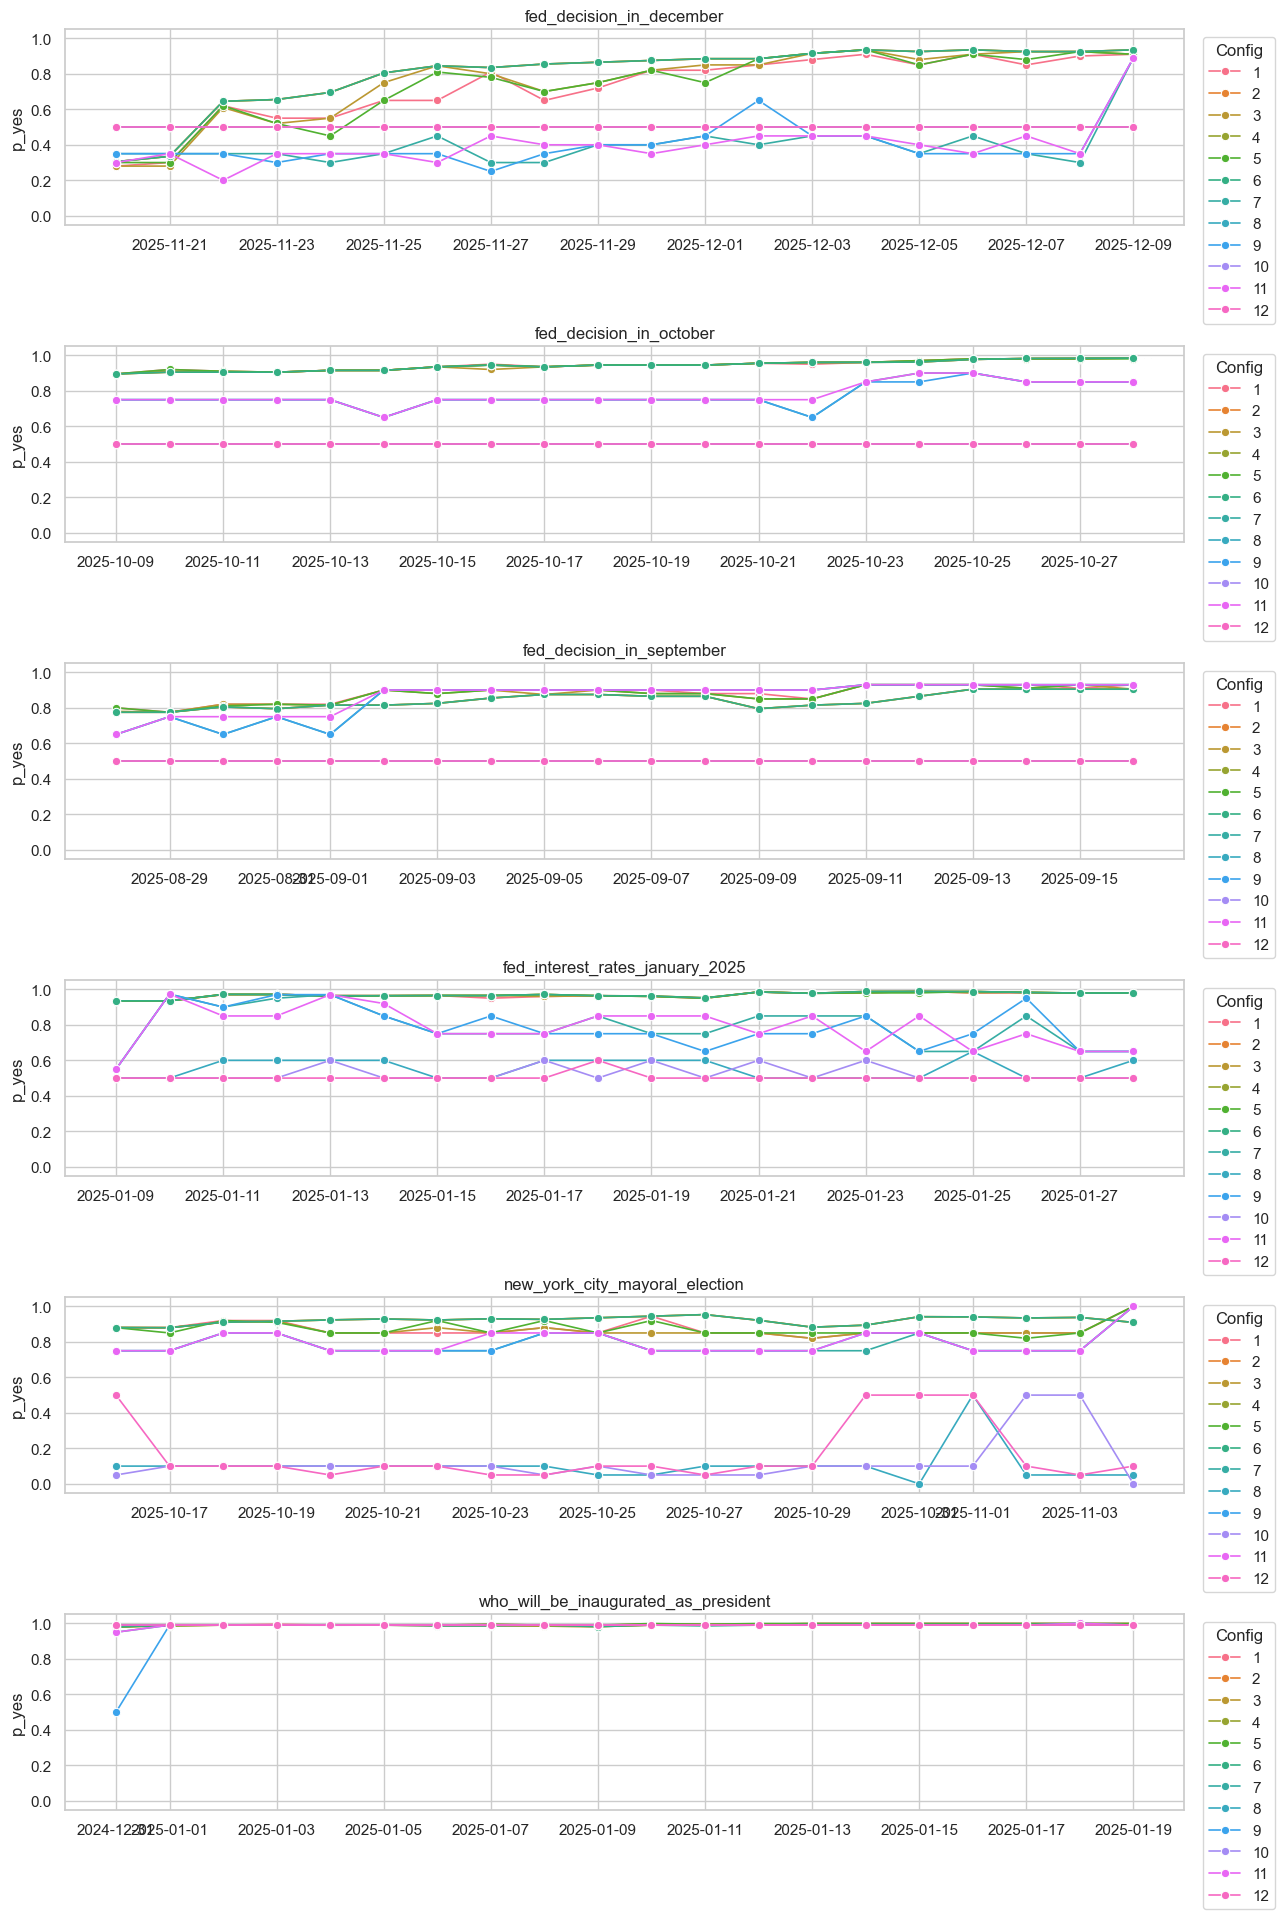

In [9]:
markets = sorted(df["market_id"].unique())
fig, axes = plt.subplots(len(markets), 1, figsize=(13, 3.2 * len(markets)), sharex=False, sharey=True)

if len(markets) == 1:
    axes = [axes]

for ax, market in zip(axes, markets):
    subset = df[df["market_id"] == market]
    sns.lineplot(
        data=subset,
        x="date",
        y="p_yes",
        hue="configuration_id",
        hue_order=[str(i) for i in range(1, 13)],
        marker="o",
        linewidth=1.2,
        ax=ax,
    )
    ax.set_title(market)
    ax.set_xlabel("")
    ax.set_ylabel("p_yes")
    ax.legend(title="Config", bbox_to_anchor=(1.01, 1), loc="upper left", ncol=1)

plt.tight_layout()
plt.savefig(output_figures_dir / "lineplots_p_yes_by_market.png", dpi=150)
plt.show()


## 6. Parni t-testi

Parne t-teste izvajamo ločeno po trgih. To pomeni, da za vsak trg primerjamo napovedi po istih datumih, pri čemer se razlikuje samo primerjani pogoj.

Na primer, pri učinku novic primerjamo `p_yes` na istem trgu in istem datumu med konfiguracijo z novicami in ustrezno konfiguracijo brez novic.


In [10]:
def paired_ttest_by_config_and_market(data: pd.DataFrame, config_a: str, config_b: str, label: str) -> pd.DataFrame:
    rows = []
    for market_id, market_data in data.groupby("market_id"):
        wide = market_data[market_data["configuration_id"].isin([config_a, config_b])].pivot(
            index="date", columns="configuration_id", values="p_yes"
        )
        wide = wide.dropna(subset=[config_a, config_b])
        diff = wide[config_a] - wide[config_b]
        n = len(diff)
        mean_diff = diff.mean()
        sd_diff = diff.std(ddof=1)
        if n < 2:
            t_stat, p_value = np.nan, np.nan
            ci_low, ci_high = np.nan, np.nan
            cohen_dz = np.nan
        elif np.isclose(sd_diff, 0):
            ci_low, ci_high = mean_diff, mean_diff
            cohen_dz = np.nan
            if np.isclose(mean_diff, 0):
                t_stat, p_value = 0.0, 1.0
            else:
                t_stat, p_value = np.sign(mean_diff) * np.inf, 0.0
        else:
            se_diff = sd_diff / np.sqrt(n)
            t_stat, p_value = stats.ttest_1samp(diff, popmean=0)
            ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean_diff, scale=se_diff)
            cohen_dz = mean_diff / sd_diff
        rows.append(
            {
                "market_id": market_id,
                "contrast": label,
                "config_a": config_a,
                "config_b": config_b,
                "n_pairs": n,
                "mean_diff_a_minus_b": mean_diff,
                "ci95_low": ci_low,
                "ci95_high": ci_high,
                "t": t_stat,
                "p_value": p_value,
                "cohen_dz": cohen_dz,
            }
        )
    return pd.DataFrame(rows)


### 6A. Učinek novic

Pozitivna razlika pomeni, da je bil `p_yes` višji, ko so bile novice prikazane.


In [11]:
news_pairs = [("1", "2"), ("3", "4"), ("5", "6"), ("7", "8"), ("9", "10"), ("11", "12")]

news_results = pd.concat(
    [paired_ttest_by_config_and_market(df, a, b, "news_shown_minus_hidden") for a, b in news_pairs],
    ignore_index=True,
)

news_results.to_csv(output_tables_dir / "paired_ttests_news_effect_by_market.csv", index=False)
news_results


,market_id,contrast,config_a,config_b,n_pairs,mean_diff_a_minus_b,ci95_low,ci95_high,t,p_value,cohen_dz
0,fed_decision_in_december,news_shown_minus_hidden,1,2,20,-0.075000,-0.103650,-0.046350,-5.479148,2.757746e-05,-1.225175
1,fed_decision_in_october,news_shown_minus_hidden,1,2,20,0.001000,-0.001278,0.003278,0.918937,3.696483e-01,0.205480
2,fed_decision_in_september,news_shown_minus_hidden,1,2,20,0.037250,0.023282,0.051218,5.581742,2.205318e-05,1.248116
3,fed_interest_rates_january_2025,news_shown_minus_hidden,1,2,20,-0.002500,-0.004537,-0.000463,-2.568506,1.880530e-02,-0.574335
4,new_york_city_mayoral_election,news_shown_minus_hidden,1,2,20,-0.048425,-0.071771,-0.025079,-4.341437,3.515822e-04,-0.970775
5,who_will_be_inaugurated_as_president,news_shown_minus_hidden,1,2,20,0.004625,0.003357,0.005893,7.635083,3.329204e-07,1.707256
6,fed_decision_in_december,news_shown_minus_hidden,3,4,20,-0.048750,-0.071989,-0.025511,-4.390769,3.142480e-04,-0.981806
7,fed_decision_in_october,news_shown_minus_hidden,3,4,20,-0.000500,-0.003470,0.002470,-0.352396,7.284200e-01,-0.078798
8,fed_decision_in_september,news_shown_minus_hidden,3,4,20,0.030000,0.016001,0.043999,4.485270,2.535199e-04,1.002937
9,fed_interest_rates_january_2025,news_shown_minus_hidden,3,4,20,-0.001600,-0.003129,-0.000071,-2.190170,4.118871e-02,-0.489737


### 6B. Učinek prikaza tržnih verjetnosti

Pozitivna razlika pomeni, da je bil `p_yes` višji, ko je model videl trenutne tržne verjetnosti.


In [12]:
market_probability_pairs = [("1", "7"), ("2", "8"), ("3", "9"), ("4", "10"), ("5", "11"), ("6", "12")]

market_probability_results = pd.concat(
    [paired_ttest_by_config_and_market(df, a, b, "market_probs_shown_minus_hidden") for a, b in market_probability_pairs],
    ignore_index=True,
)

market_probability_results.to_csv(output_tables_dir / "paired_ttests_market_probability_effect_by_market.csv", index=False)
market_probability_results


,market_id,contrast,config_a,config_b,n_pairs,mean_diff_a_minus_b,ci95_low,ci95_high,t,p_value,cohen_dz
0,fed_decision_in_december,market_probs_shown_minus_hidden,1,7,20,0.324500,0.236215,0.412785,7.693122,2.981368e-07,1.720234
1,fed_decision_in_october,market_probs_shown_minus_hidden,1,7,20,0.168725,0.142984,0.194466,13.718967,2.617739e-11,3.067654
2,fed_decision_in_september,market_probs_shown_minus_hidden,1,7,20,0.023750,-0.006284,0.053784,1.655124,1.143239e-01,0.370097
3,fed_interest_rates_january_2025,market_probs_shown_minus_hidden,1,7,20,0.177250,0.120872,0.233628,6.580419,2.676470e-06,1.471426
4,new_york_city_mayoral_election,market_probs_shown_minus_hidden,1,7,20,0.084725,0.062289,0.107161,7.903927,2.004437e-07,1.767372
5,who_will_be_inaugurated_as_president,market_probs_shown_minus_hidden,1,7,20,0.005925,0.002668,0.009182,3.807622,1.188909e-03,0.851410
6,fed_decision_in_december,market_probs_shown_minus_hidden,2,8,20,0.299000,0.211595,0.386405,7.159968,8.357165e-07,1.601017
7,fed_decision_in_october,market_probs_shown_minus_hidden,2,8,20,0.442725,0.429361,0.456089,69.338714,2.576162e-24,15.504608
8,fed_decision_in_september,market_probs_shown_minus_hidden,2,8,20,0.343000,0.322258,0.363742,34.611076,1.253397e-18,7.739272
9,fed_interest_rates_january_2025,market_probs_shown_minus_hidden,2,8,20,0.416900,0.390288,0.443512,32.788650,3.446871e-18,7.331765


### 6C. Učinek informacije o drugih udeležencih trga

To je za trenutno nalogo najpomembnejši del. Primerjamo, ali se napovedi razlikujejo, če je v pozivu zapisano, da so drugi udeleženci:

- LLM agenti,
- človeški traderji,
- ali pa drugi udeleženci niso omenjeni.

Primerjave izvajamo tako, da držimo prikaz tržnih verjetnosti in novice konstantne.


In [13]:
trader_pairs = [
    ("1", "3", "llms_minus_humans | market_probs=True, news=True"),
    ("1", "5", "llms_minus_none | market_probs=True, news=True"),
    ("3", "5", "humans_minus_none | market_probs=True, news=True"),
    ("2", "4", "llms_minus_humans | market_probs=True, news=False"),
    ("2", "6", "llms_minus_none | market_probs=True, news=False"),
    ("4", "6", "humans_minus_none | market_probs=True, news=False"),
    ("7", "9", "llms_minus_humans | market_probs=False, news=True"),
    ("7", "11", "llms_minus_none | market_probs=False, news=True"),
    ("9", "11", "humans_minus_none | market_probs=False, news=True"),
    ("8", "10", "llms_minus_humans | market_probs=False, news=False"),
    ("8", "12", "llms_minus_none | market_probs=False, news=False"),
    ("10", "12", "humans_minus_none | market_probs=False, news=False"),
]

trader_results = pd.concat(
    [paired_ttest_by_config_and_market(df, a, b, label) for a, b, label in trader_pairs],
    ignore_index=True,
)

trader_results.to_csv(output_tables_dir / "paired_ttests_trader_framing_effect_by_market.csv", index=False)
trader_results


,market_id,contrast,config_a,config_b,n_pairs,mean_diff_a_minus_b,ci95_low,ci95_high,t,p_value,cohen_dz
0,fed_decision_in_december,"llms_minus_humans | market_probs=True, news=True",1,3,20,-0.026250,-0.050028,-0.002472,-2.310624,0.032242,-0.516671
1,fed_decision_in_october,"llms_minus_humans | market_probs=True, news=True",1,3,20,0.001500,-0.001987,0.004987,0.900237,0.379263,0.201299
2,fed_decision_in_september,"llms_minus_humans | market_probs=True, news=True",1,3,20,0.007250,0.001249,0.013251,2.528667,0.020463,0.565427
3,fed_interest_rates_january_2025,"llms_minus_humans | market_probs=True, news=True",1,3,20,-0.000900,-0.002475,0.000675,-1.195673,0.246534,-0.267361
4,new_york_city_mayoral_election,"llms_minus_humans | market_probs=True, news=True",1,3,20,0.003925,-0.006616,0.014466,0.779354,0.445371,0.174269
...,...,...,...,...,...,...,...,...,...,...,...
67,fed_decision_in_october,"humans_minus_none | market_probs=False, news=F...",10,12,20,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
68,fed_decision_in_september,"humans_minus_none | market_probs=False, news=F...",10,12,20,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
69,fed_interest_rates_january_2025,"humans_minus_none | market_probs=False, news=F...",10,12,20,0.020000,-0.004484,0.044484,1.709701,0.103603,0.382301
70,new_york_city_mayoral_election,"humans_minus_none | market_probs=False, news=F...",10,12,20,-0.045000,-0.153677,0.063677,-0.866659,0.396942,-0.193791
